# 4. Wave boundaries

**What this shows:** the two ways to bring waves into a SWAN model, parametric
spectra and spectra from a larger wave model, and how they change the results.

**Prerequisites:** [3. Input grids: bathymetry and wind](03_input_grids.ipynb).

**You will learn:**

- what SWAN assumes on boundaries without wave information
- how `BOUNDSPEC` prescribes a parametric spectrum on one side
- how `Boundnest1` selects spectra from a regional wave model along every open
  boundary, and how to check them
- which boundary class fits your data

**Data used:** `etopo15s_perth.nc` (bathymetry) and `ww3-spectra-20230101-short.nc`
(3-hourly WAVEWATCH III spectra at 19 sites off Perth).

## Setup

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import wavespectra
import xarray as xr
from rompy.logging import config as logging_config

logging_config.update(level="WARNING")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "04_wave_boundaries"
shutil.rmtree(OUT_DIR, ignore_errors=True)
OUT_DIR.mkdir(parents=True)

## 1. What SWAN knows about incoming waves

SWAN only knows the waves that enter through its boundaries. On a boundary without
wave information it assumes that no waves come in, and the missing energy spreads
into the domain as a shadow from the corners, as in
[Tutorial 1](01_first_model.ipynb). Place those boundaries far from the area of
interest, or give waves on every open boundary.

We use the grid and bathymetry of the previous tutorials, at 15:00 on 1 January 2023.

In [2]:
from rompy.core.source import SourceFile
from rompy.core.time import TimeRange
from rompy_swan.data import SwanDataGrid
from rompy_swan.grid import SwanGrid
from rompy_swan.interface import DataInterface

grid = SwanGrid(x0=114.5, y0=-32.8, dx=0.02, dy=0.02, nx=71, ny=66)
period = TimeRange(start="2023-01-01T15:00", end="2023-01-01T16:00", interval="1h")
bottom = SwanDataGrid(
    var="bottom",
    source=SourceFile(uri=DATA_DIR / "etopo15s_perth.nc"),
    z1="z",
    fac=-1.0,
    coords={"x": "longitude", "y": "latitude"},
    buffer=0.1,
)

## 2. A parametric boundary

`BOUNDSPEC` describes the incoming spectrum by a few parameters, on one side or
segment of the grid:

- `SHAPESPEC`: the spectral shape (here JONSWAP, with peak enhancement `gamma`), whether
  the period is the peak or the mean, and whether spreading is in degrees or as a
  power of cosine;
- `SIDE`: which side, and the direction to follow along it;
- `CONSTANTPAR`: the significant wave height, period, direction and spreading.

In [3]:
from rompy_swan.components.boundary import BOUNDSPEC
from rompy_swan.subcomponents.boundary import CONSTANTPAR, SIDE
from rompy_swan.subcomponents.spectrum import JONSWAP, SHAPESPEC

parametric = BOUNDSPEC(
    shapespec=SHAPESPEC(shape=JONSWAP(gamma=3.3), per_type="peak", dspr_type="degrees"),
    location=SIDE(side="west", direction="ccw"),
    data=CONSTANTPAR(hs=2.0, per=12.0, dir=240.0, dd=20.0),
)
print(parametric.render())

BOUND SHAPESPEC JONSWAP gamma=3.3 PEAK DSPR DEGREES
BOUNDSPEC SIDE WEST CCW CONSTANT PAR hs=2.0 per=12.0 dir=240.0 dd=20.0


It suits idealised studies, or a boundary far offshore where the waves are uniform.
[Parametric boundaries](../examples/boundaries_parametric.ipynb) shows the other
shapes, segments and time-varying parameters.

## 3. Spectra from a regional wave model

Operational and hindcast models such as WAVEWATCH III write spectra at output sites.
Here are the 19 sites in the example data, coloured by their wave height at 15:00.
`SourceWavespectra` opens them with a [wavespectra](https://wavespectra.readthedocs.io)
reader.

In [4]:
from rompy.core.source import SourceWavespectra

source = SourceWavespectra(
    uri=DATA_DIR / "ww3-spectra-20230101-short.nc", reader="read_ww3"
)
sites = source.open().sel(time="2023-01-01T15:00")
sites

<xarray.Dataset> Size: 57kB
Dimensions:  (site: 19, freq: 31, dir: 24)
Coordinates:
  * site     (site) int64 152B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18
  * freq     (freq) float32 124B 0.037 0.0407 0.04477 ... 0.5336 0.5869 0.6456
  * dir      (dir) float32 96B 270.0 255.0 240.0 225.0 ... 315.0 300.0 285.0
    time     datetime64[ns] 8B 2023-01-01T15:00:00
Data variables:
    dpt      (site) float32 76B dask.array<chunksize=(19,), meta=np.ndarray>
    efth     (site, freq, dir) float32 57kB dask.array<chunksize=(19, 31, 24), meta=np.ndarray>
    lat      (site) float32 76B dask.array<chunksize=(19,), meta=np.ndarray>
    lon      (site) float32 76B dask.array<chunksize=(19,), meta=np.ndarray>
    wdir     (site) float32 76B dask.array<chunksize=(19,), meta=np.ndarray>
    wspd     (site) float32 76B dask.array<chunksize=(19,), meta=np.ndarray>
Attributes: (12/17)
    altitude_resolution:    n/a
    area:                   Global 0.5 x 0.5 degree
    data_type:              OCO spectra 2D
    easternmost_longitude:  n/a
    field_type:             3-hourly
    format_version:         wavespectra
    ...                     ...
    product_name:           ww3-spectra-20230101-short.nc
    southernmost_latitude:  n/a
    start_date:             2023-01-01 00:00:00
    stop_date:              2023-01-02 00:00:00
    westernmost_longitude:  n/a
    Conventions:            WAVEWATCHIII

`Boundnest1` selects spectra at points along every open boundary of the grid, writes
them to a SWAN spectral file and returns the `BOUNDNEST1` command:

- `sel_method`: interpolate between sites (`idw`, inverse distance weighting) or take
  the `nearest` one;
- `sel_method_kwargs`: here the `tolerance`, the largest distance (in degrees) to use a
  site. The sites are 0.5° apart, and the eastern corners of the grid are more than
  1° from the nearest one;
- `spacing`: the distance between boundary points, here 0.1°.

In [5]:
from rompy_swan.boundary import Boundnest1

spectral = Boundnest1(
    id="ww3",
    source=source,
    sel_method="idw",
    sel_method_kwargs={"tolerance": 1.5},
    spacing=0.1,
)
bnd_file, cmd = spectral.get(OUT_DIR, grid=grid, time=period)
print(cmd)

BOUNDNEST1 NEST 'ww3.bnd' CLOSED


Always check the boundary against its source before running the model. The file can
be read back with wavespectra: the colours along the boundary should continue those
of the nearby sites.

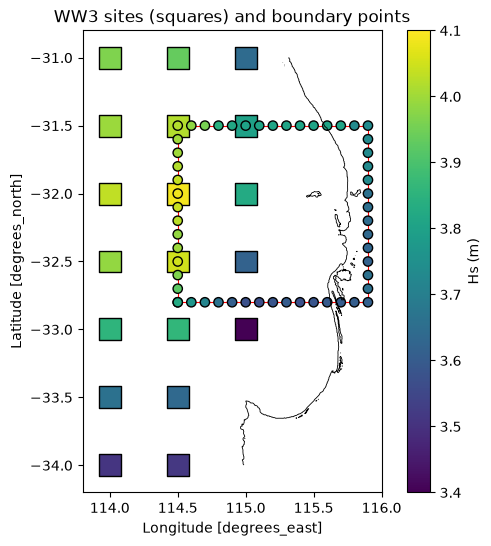

In [6]:
boundary = wavespectra.read_swan(bnd_file)
etopo = xr.open_dataset(DATA_DIR / "etopo15s_perth.nc")
hs_kwargs = {"cmap": "viridis", "vmin": 3.4, "vmax": 4.1, "edgecolors": "k"}

fig, ax = plt.subplots(figsize=(6.5, 6))
etopo.z.plot.contour(ax=ax, levels=[0], colors="k", linewidths=0.6)
ax.scatter(sites.lon, sites.lat, c=sites.spec.hs(), s=250, marker="s", **hs_kwargs)
pts = ax.scatter(
    boundary.lon, boundary.lat, c=boundary.spec.hs().isel(time=0), s=45, **hs_kwargs
)
x0, y0, x1, y1 = grid.bbox()
ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], "r", linewidth=0.8, zorder=0)
fig.colorbar(pts, ax=ax, label="Hs (m)")
ax.set(xlim=(113.8, 116), ylim=(-34.2, -30.8), title="WW3 sites (squares) and boundary points")
ax.set_aspect("equal");

`BoundaryInterface` wraps a data-driven boundary for `SwanConfig`. The spectral file
has times, so the model needs `MODE NONSTATIONARY`, as the wind did in
[Tutorial 3](03_input_grids.ipynb).

## 4. Comparing the two boundaries

To see only the effect of the boundary, both models have no wind: they propagate the
incoming waves to the coast. Without wind, SWAN requires the quadruplet interactions
to be switched off.

In [7]:
from rompy_swan.components.cgrid import REGULAR
from rompy_swan.components.group import LOCKUP, OUTPUT, PHYSICS, STARTUP
from rompy_swan.components.lockup import COMPUTE_STAT
from rompy_swan.components.output import BLOCK
from rompy_swan.components.physics import GEN3, OFF, OFFS
from rompy_swan.components.startup import COORDINATES, MODE, SET
from rompy_swan.config import SwanConfig
from rompy_swan.interface import BoundaryInterface
from rompy_swan.subcomponents.spectrum import SPECTRUM
from rompy_swan.subcomponents.startup import SPHERICAL


def swan_config(boundary) -> SwanConfig:
    """The model of the previous tutorials, without wind, with the given boundary."""
    return SwanConfig(
        startup=STARTUP(
            set=SET(direction_convention="nautical"),
            mode=MODE(kind="nonstationary"),
            coordinates=COORDINATES(kind=SPHERICAL()),
        ),
        cgrid=REGULAR(grid=grid.component, spectrum=SPECTRUM(mdc=36, flow=0.04, fhigh=1.0)),
        inpgrid=DataInterface(bottom=bottom),
        boundary=boundary,
        physics=PHYSICS(gen=GEN3(), deactivate=OFFS(offs=[OFF(physics="quadrupl")])),
        output=OUTPUT(
            block=BLOCK(sname="COMPGRID", fname="swangrid.nc", output=["hsign", "dir"])
        ),
        lockup=LOCKUP(compute=COMPUTE_STAT()),
    )


configs = {
    "parametric": swan_config(parametric),
    "spectral": swan_config(BoundaryInterface(kind=spectral)),
}

In [8]:
from rompy.backends import DockerConfig
from rompy.model import ModelRun


def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


backend = DockerConfig(image="ghcr.io/rom-py/swan:41.51", executable="swan.exe")
workspaces = {}
for name, config in configs.items():
    modelrun = ModelRun(run_id=name, period=period, output_dir=OUT_DIR, config=config)
    workspaces[name] = Path(modelrun())
    if docker_available():
        ok = modelrun.run(backend, workspace_dir=workspaces[name])
        print(f"{name}: {'SWAN finished successfully' if ok else 'SWAN failed'}")
    else:
        print("Docker is not available, skipping the model runs")

parametric: SWAN finished successfully


spectral: SWAN finished successfully


With spectra on every open side, the shadow along the southern boundary disappears.
The waves are also higher: the WW3 model had about 3.7 m offshore at this time, not
the 2 m we assumed.

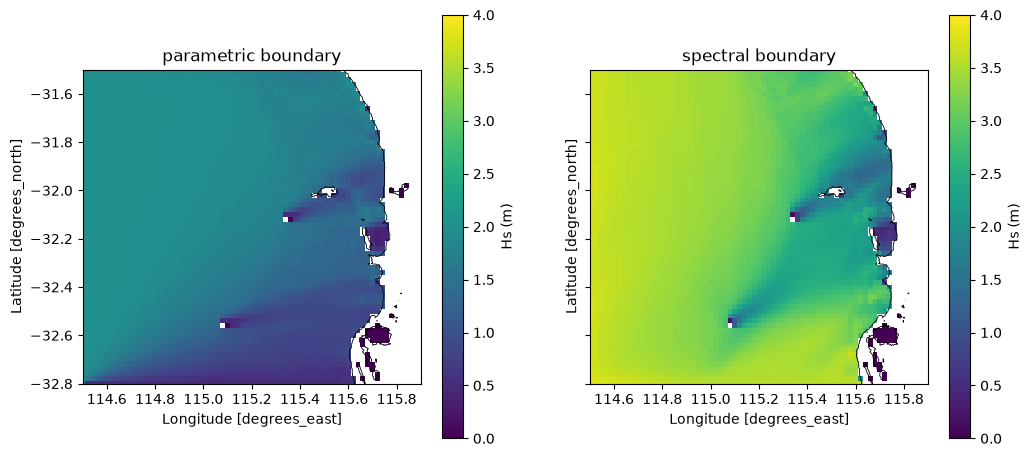

In [9]:
if all((ws / "swangrid.nc").exists() for ws in workspaces.values()):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
    for ax, (name, ws) in zip(axes, workspaces.items()):
        ds = xr.open_dataset(ws / "swangrid.nc").isel(time=0)
        ds.hs.plot(ax=ax, cmap="viridis", vmin=0, vmax=4, cbar_kwargs={"label": "Hs (m)"})
        etopo.z.plot.contour(ax=ax, levels=[0], colors="k", linewidths=0.6)
        ax.set(xlim=(114.5, 115.9), ylim=(-32.8, -31.5), title=f"{name} boundary")
        ax.set_aspect("equal")

## 5. Which boundary class do I need?

| Your data | Use | Example |
|---|---|---|
| Wave parameters, or idealised waves | `BOUNDSPEC` with `CONSTANTPAR` or a TPAR file | [Parametric boundaries](../examples/boundaries_parametric.ipynb) |
| Spectra at sites or on a grid (WW3, other models) | `Boundnest1` for all open sides; `BoundspecSide` or `BoundspecSegmentXY` for one side or segments | [Boundaries from spectra](../examples/boundaries_from_spectra.ipynb) |
| A larger SWAN run | `NESTOUT` in the parent, `BOUNDNEST1` in the child | [Nesting](../examples/nesting.ipynb) |
| WAVEWATCH III boundary files (`ww3_outp`) | `BOUNDNEST3` | [Boundaries from spectra](../examples/boundaries_from_spectra.ipynb) |

## Summary

- SWAN assumes no waves enter where no boundary is given, which casts shadows from
  the corners.
- `BOUNDSPEC` prescribes a parametric spectrum on one side or segment.
- `Boundnest1` interpolates spectra from a regional model along every open boundary;
  check the boundary against its source before running.
- Data-driven boundaries have times, so they need `MODE NONSTATIONARY`.

**Next:** [5. Choosing model settings](05_model_settings.ipynb).